# DSA 210 Project
## Data Collection, EDA, and Hypothesis Testing

This notebook contains the April 14 stage of my DSA 210 project. It includes data collection, data cleaning, exploratory data analysis, and hypothesis testing on house price datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## 2. Reading the Datasets

The datasets are loaded into pandas DataFrames for further preprocessing and analysis.

In [ ]:
df_main = pd.read_csv("train.csv")
df_alt = pd.read_csv("house_price_prediction.csv")

In [ ]:
print("Main dataset shape:", df_main.shape)
print("Alternative dataset shape:", df_alt.shape)

Main dataset shape: (1460, 81)
Alternative dataset shape: (2000, 10)


In [ ]:
df_main.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df_alt.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## 3. Data Overview

This section provides a general overview of both datasets, including their structure, variable types, and missing values.

In [ ]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df_alt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df_main.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df_alt.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
df_main.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [ ]:
df_alt.isnull().sum().sort_values(ascending=False)

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
if "Id" in df_main.columns:
    df_main = df_main.drop("Id", axis=1)

df_main.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
num_cols = df_main.select_dtypes(include=[np.number]).columns
cat_cols = df_main.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    df_main[col] = df_main[col].fillna(df_main[col].median())

for col in cat_cols:
    df_main[col] = df_main[col].fillna(df_main[col].mode()[0])

print(df_main.isnull().sum().sum())

0


In [ ]:
df_main["HouseAge"] = df_main["YrSold"] - df_main["YearBuilt"]
df_main["RemodAge"] = df_main["YrSold"] - df_main["YearRemodAdd"]
df_main["TotalSF"] = df_main["TotalBsmtSF"] + df_main["1stFlrSF"] + df_main["2ndFlrSF"]
df_main["HasGarage"] = np.where(df_main["GarageArea"] > 0, 1, 0)

df_main[["HouseAge", "RemodAge", "TotalSF", "HasGarage"]].head()

,HouseAge,RemodAge,TotalSF,HasGarage
0,5,5,2566,1
1,31,31,2524,1
2,7,6,2706,1
3,91,36,2473,1
4,8,8,3343,1


## 5. Exploratory Data Analysis (EDA)

In this section, I explore the distribution of house prices and examine how important housing features are related to sale price.

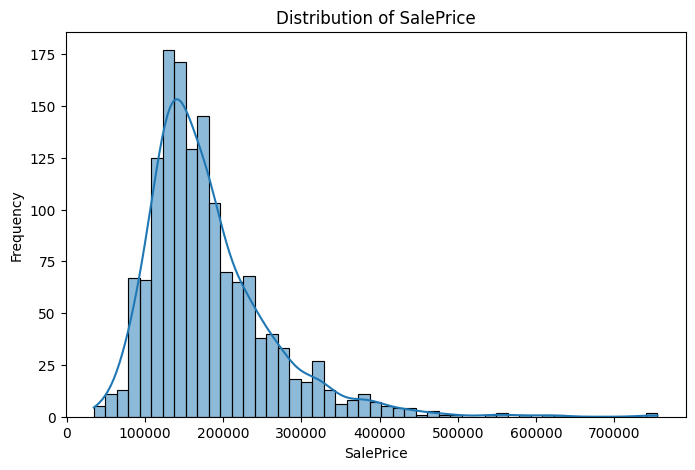

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_main["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

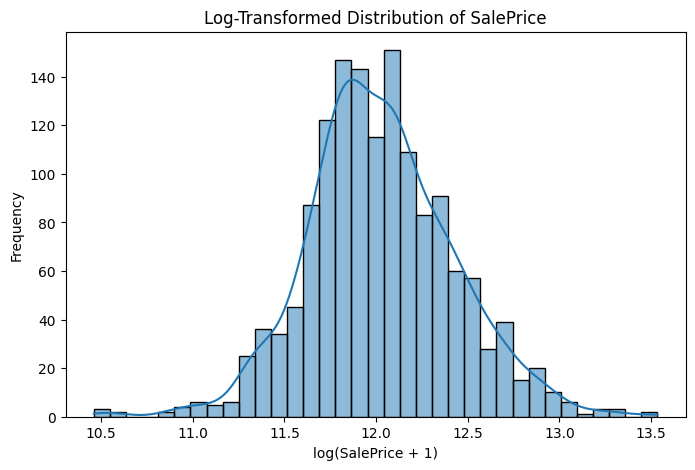

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_main["SalePrice"]), kde=True)
plt.title("Log-Transformed Distribution of SalePrice")
plt.xlabel("log(SalePrice + 1)")
plt.ylabel("Frequency")
plt.show()

The distribution of sale prices appears to be right-skewed. After applying a log transformation, the distribution becomes more symmetric, which suggests that transformation may be useful in the modeling stage.

In [ ]:
corr = df_main.select_dtypes(include=[np.number]).corr()["SalePrice"].sort_values(ascending=False)
corr.head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
TotalSF,0.782260
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723


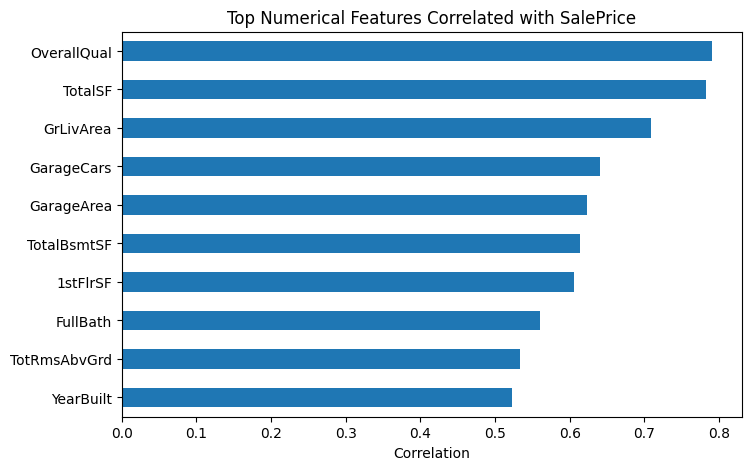

In [ ]:
top_corr = corr[1:11]

plt.figure(figsize=(8,5))
top_corr.sort_values().plot(kind="barh")
plt.title("Top Numerical Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.show()

The strongest numerical relationships with sale price appear to involve overall quality, living area, garage-related variables, and total square footage. These variables will be examined further in the following visualizations.

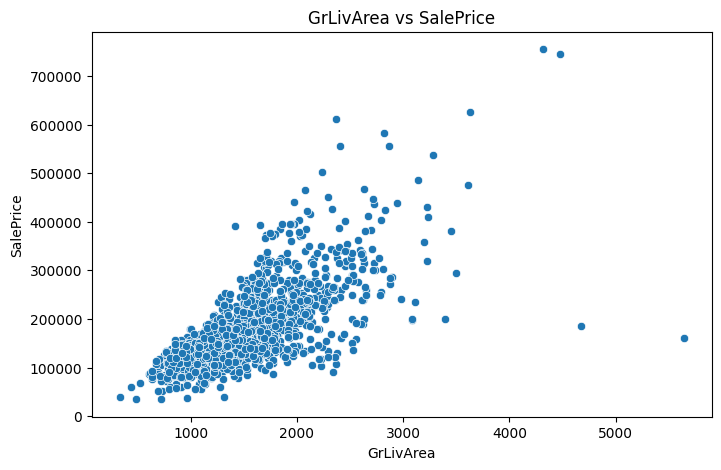

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_main["GrLivArea"], y=df_main["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

The scatterplot suggests a positive relationship between above-ground living area and sale price. In general, larger houses tend to have higher sale values.

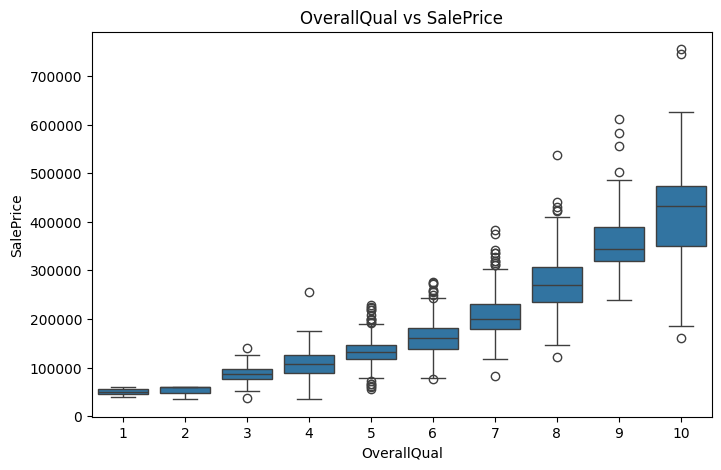

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_main["OverallQual"], y=df_main["SalePrice"])
plt.title("OverallQual vs SalePrice")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.show()

The boxplot shows that higher quality levels are associated with higher sale prices. There is a clear upward trend as overall quality increases.

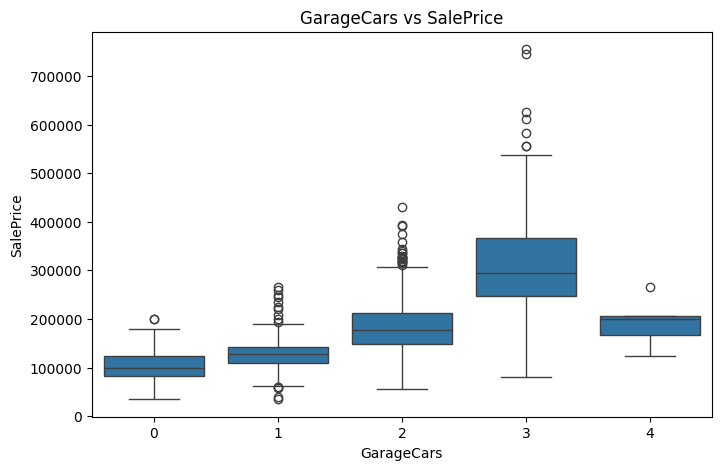

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_main["GarageCars"], y=df_main["SalePrice"])
plt.title("GarageCars vs SalePrice")
plt.xlabel("GarageCars")
plt.ylabel("SalePrice")
plt.show()

Houses with larger garage capacity tend to have higher sale prices, although there is still noticeable variation within each group.

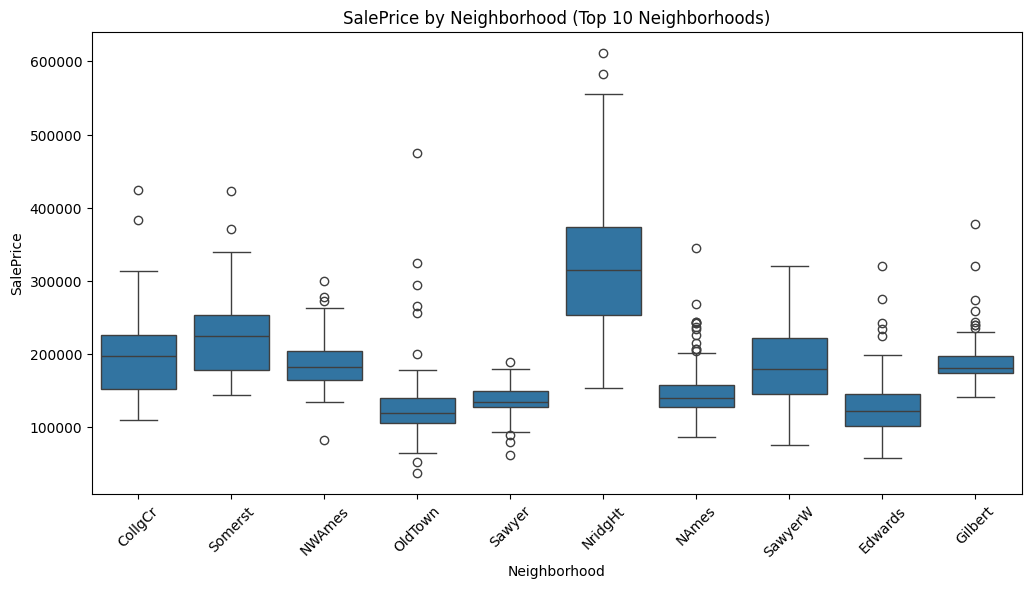

In [ ]:
top_neighborhoods = df_main["Neighborhood"].value_counts().head(10).index
subset = df_main[df_main["Neighborhood"].isin(top_neighborhoods)]

plt.figure(figsize=(12,6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=subset)
plt.xticks(rotation=45)
plt.title("SalePrice by Neighborhood (Top 10 Neighborhoods)")
plt.show()

Sale prices vary across neighborhoods, which suggests that location is an important factor in housing valuation.

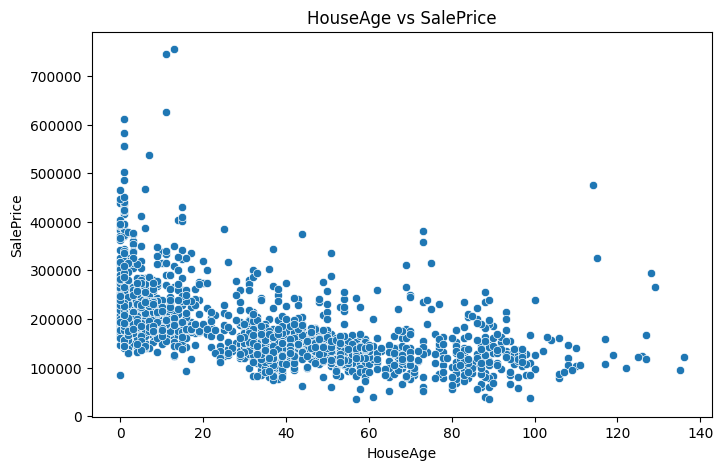

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_main["HouseAge"], y=df_main["SalePrice"])
plt.title("HouseAge vs SalePrice")
plt.xlabel("HouseAge")
plt.ylabel("SalePrice")
plt.show()

Older houses do not necessarily have lower sale prices in every case, but the plot suggests that house age may still have some relationship with price.

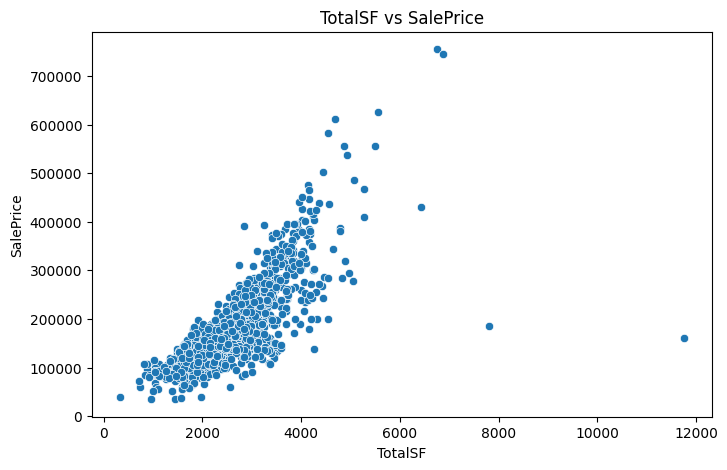

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_main["TotalSF"], y=df_main["SalePrice"])
plt.title("TotalSF vs SalePrice")
plt.xlabel("TotalSF")
plt.ylabel("SalePrice")
plt.show()

The total square footage variable also shows a positive association with sale price. Larger properties tend to be sold at higher prices.

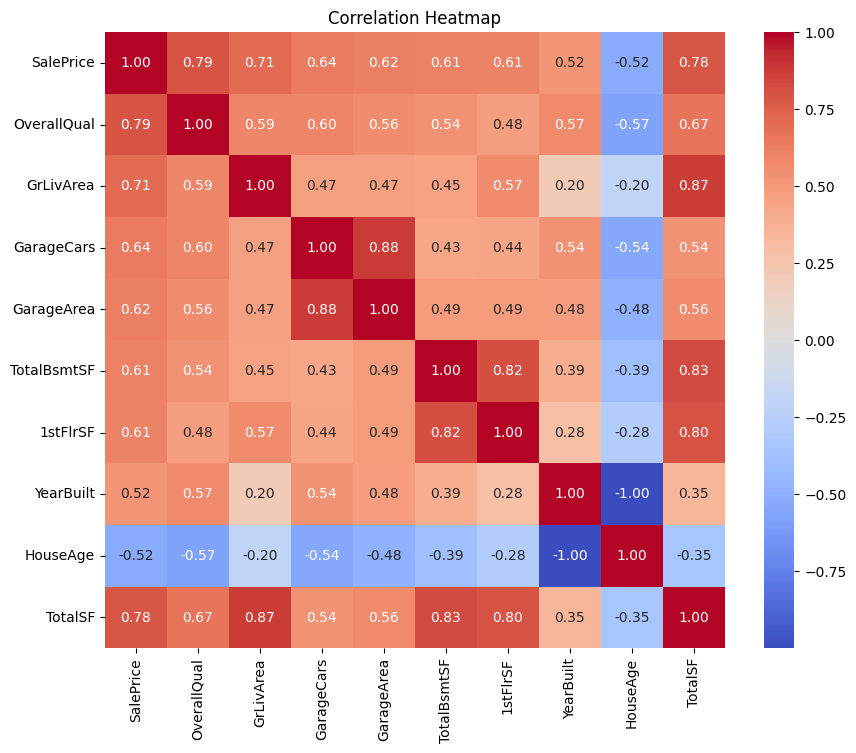

In [ ]:
selected_cols = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
                 "TotalBsmtSF", "1stFlrSF", "YearBuilt", "HouseAge", "TotalSF"]

plt.figure(figsize=(10,8))
sns.heatmap(df_main[selected_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap confirms that several structural and quality-related variables are strongly associated with sale price. It also shows that some of these variables are related to each other, which may be important during the modeling stage.

## 6. Hypothesis Testing

In this section, I test whether some important housing characteristics are significantly related to sale price.

### Hypothesis 1: Garage Presence and Sale Price

**H0:** There is no significant difference in sale prices between houses with garages and houses without garages.  
**H1:** There is a significant difference in sale prices between houses with garages and houses without garages.

In [52]:
garage_yes = df_main[df_main["HasGarage"] == 1]["SalePrice"]
garage_no = df_main[df_main["HasGarage"] == 0]["SalePrice"]

t_stat, p_val = stats.ttest_ind(garage_yes, garage_no, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 19.461950104195076
P-value: 5.259826011785932e-42


Since the p-value is below 0.05, the null hypothesis is rejected. This suggests that houses with garages and houses without garages differ significantly in terms of sale price.

### Hypothesis 2: Overall Quality and Sale Price

**H0:** The mean sale prices are equal across different overall quality levels.  
**H1:** At least one quality group has a different mean sale price.

In [53]:
groups = [group["SalePrice"].values for _, group in df_main.groupby("OverallQual")]
f_stat, p_val = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_val)

F-statistic: 349.02683956930764
P-value: 0.0


The null hypothesis is rejected because the p-value is far below 0.05. This indicates that sale prices differ significantly across overall quality levels.

In [54]:
corr_coef, p_val = stats.pearsonr(df_main["GrLivArea"], df_main["SalePrice"])

print("Pearson correlation:", corr_coef)
print("P-value:", p_val)

Pearson correlation: 0.7086244776126522
P-value: 4.518033646776293e-223


The null hypothesis is rejected. The results show a statistically significant positive relationship between above-ground living area and sale price. The correlation coefficient also indicates a strong positive association.

In [55]:
top5_neighborhoods = df_main["Neighborhood"].value_counts().head(5).index
subset = df_main[df_main["Neighborhood"].isin(top5_neighborhoods)]

groups = [group["SalePrice"].values for _, group in subset.groupby("Neighborhood")]
f_stat, p_val = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_val)

F-statistic: 100.32874255270399
P-value: 6.842662154601675e-67


The null hypothesis is rejected. This suggests that sale prices vary significantly across the selected neighborhoods.

## 7. Initial Findings

The exploratory analysis and hypothesis tests show that house prices are strongly associated with several important housing characteristics. In particular, variables such as overall quality, living area, garage-related features, and neighborhood appear to have significant relationships with sale price. The results suggest that these variables are likely to be useful in the next stage of the project, where machine learning models will be applied for house price prediction.